In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chaithanyakumar1449","key":"68bde0d9531c301ab1e656182ea4e66c"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten


Dataset URL: https://www.kaggle.com/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten
License(s): CC0-1.0
 99% 4.70G/4.77G [02:00<00:04, 15.1MB/s]
100% 4.77G/4.77G [02:00<00:00, 42.5MB/s]


In [ ]:
!unzip fruit-and-vegetable-disease-healthy-vs-rotten.zip -d dataset


Streaming output truncated to the last 5000 lines.
  inflating: dataset/Fruit And Vegetable Diseases Dataset/Potato__Healthy/freshPotato (85).jpg  
  inflating: dataset/Fruit And Vegetable Diseases Dataset/Potato__Healthy/freshPotato (86).jpg  
  inflating: dataset/Fruit And Vegetable Diseases Dataset/Potato__Healthy/freshPotato (87).jpg  
  inflating: dataset/Fruit And Vegetable Diseases Dataset/Potato__Healthy/freshPotato (88).jpg  
  inflating: dataset/Fruit And Vegetable Diseases Dataset/Potato__Healthy/freshPotato (89).jpg  
  inflating: dataset/Fruit And Vegetable Diseases Dataset/Potato__Healthy/freshPotato (9).jpg  
  inflating: dataset/Fruit And Vegetable Diseases Dataset/Potato__Healthy/freshPotato (90).jpg  
  inflating: dataset/Fruit And Vegetable Diseases Dataset/Potato__Healthy/freshPotato (91).jpg  
  inflating: dataset/Fruit And Vegetable Diseases Dataset/Potato__Healthy/freshPotato (92).jpg  
  inflating: dataset/Fruit And Vegetable Diseases Dataset/Potato__Healthy/fre

In [ ]:
import os

import shutil

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split

import shutil

from sklearn.model_selection import train_test_split

from tensorflow.keras.applications.vgg16 import VGG16

from tensorflow.keras.layers import Dense, Flatten

from tensorflow.keras.models import Model

from keras.callbacks import EarlyStopping

from keras.optimizers import Adam

from tensorflow.keras.applications.resnet50 import ResNet50

from tensorflow.keras.layers import Dense, Flatten

from tensorflow.keras.models import Model

from keras.preprocessing import image

from keras.applications.vgg16 import preprocess_input

from tensorflow.keras.preprocessing.image import load_img, img_to_array

import random

from IPython.display import Image, display


In [ ]:
dataset_dir = 'dataset/Fruit And Vegetable Diseases Dataset'
classes=os.listdir(dataset_dir)


In [ ]:
import os

print(os.listdir("dataset"))
print(os.listdir("dataset/Fruit And Vegetable Diseases Dataset"))
print(classes)#Both classes and 2nd print statement are same

['Fruit And Vegetable Diseases Dataset']
['Bellpepper__Healthy', 'Guava__Rotten', 'Banana__Rotten', 'Orange__Rotten', 'Grape__Healthy', 'Jujube__Healthy', 'Pomegranate__Healthy', 'Potato__Rotten', 'Carrot__Rotten', 'Apple__Healthy', 'Mango__Healthy', 'Tomato__Rotten', 'Orange__Healthy', 'Strawberry__Rotten', 'Apple__Rotten', 'Grape__Rotten', 'Jujube__Rotten', 'Guava__Healthy', 'Cucumber__Healthy', 'Carrot__Healthy', 'Potato__Healthy', 'Pomegranate__Rotten', 'Tomato__Healthy', 'Strawberry__Healthy', 'Bellpepper__Rotten', 'Mango__Rotten', 'Cucumber__Rotten', 'Banana__Healthy']
['Bellpepper__Healthy', 'Guava__Rotten', 'Banana__Rotten', 'Orange__Rotten', 'Grape__Healthy', 'Jujube__Healthy', 'Pomegranate__Healthy', 'Potato__Rotten', 'Carrot__Rotten', 'Apple__Healthy', 'Mango__Healthy', 'Tomato__Rotten', 'Orange__Healthy', 'Strawberry__Rotten', 'Apple__Rotten', 'Grape__Rotten', 'Jujube__Rotten', 'Guava__Healthy', 'Cucumber__Healthy', 'Carrot__Healthy', 'Potato__Healthy', 'Pomegranate__Rotten

In [ ]:
noutput_dir = 'output_dataset'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, 'train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'val'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'test'), exist_ok=True)


NameError: name 'output_dir' is not defined

In [ ]:
for cls in classes:
    os.makedirs(os.path.join(output_dir, 'train', cls), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'val', cls), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'test', cls), exist_ok=True)

    class_dir = os.path.join(dataset_dir, cls)
    images = os.listdir(class_dir)[:200]

    train_and_val_images, test_images = train_test_split(images, test_size=0.2, random_state=42)
    train_images, val_images = train_test_split(train_and_val_images, test_size=0.25, random_state=42)


    for img in train_images:
        shutil.copy(os.path.join(class_dir, img), os.path.join(output_dir, 'train', cls, img))

    for img in val_images:
        shutil.copy(os.path.join(class_dir, img), os.path.join(output_dir, 'val', cls, img))

    for img in test_images:
        shutil.copy(os.path.join(class_dir, img), os.path.join(output_dir, 'test', cls, img))



In [ ]:
    print("Dataset split into training, validation, and test sets.")



Dataset split into training, validation, and test sets.


In [ ]:
dataset_dir = '/content/output_dataset'
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')
test_dir = os.path.join(dataset_dir, 'test')

In [ ]:
IMG_SIZE = (224, 224)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
val_test_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

Found 3358 images belonging to 28 classes.


In [ ]:
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)


Found 1120 images belonging to 28 classes.


In [ ]:
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 1119 images belonging to 28 classes.


In [ ]:
print(train_generator.class_indices)
print(val_generator.class_indices)
print(test_generator.class_indices)


{'Apple__Healthy': 0, 'Apple__Rotten': 1, 'Banana__Healthy': 2, 'Banana__Rotten': 3, 'Bellpepper__Healthy': 4, 'Bellpepper__Rotten': 5, 'Carrot__Healthy': 6, 'Carrot__Rotten': 7, 'Cucumber__Healthy': 8, 'Cucumber__Rotten': 9, 'Grape__Healthy': 10, 'Grape__Rotten': 11, 'Guava__Healthy': 12, 'Guava__Rotten': 13, 'Jujube__Healthy': 14, 'Jujube__Rotten': 15, 'Mango__Healthy': 16, 'Mango__Rotten': 17, 'Orange__Healthy': 18, 'Orange__Rotten': 19, 'Pomegranate__Healthy': 20, 'Pomegranate__Rotten': 21, 'Potato__Healthy': 22, 'Potato__Rotten': 23, 'Strawberry__Healthy': 24, 'Strawberry__Rotten': 25, 'Tomato__Healthy': 26, 'Tomato__Rotten': 27}
{'Apple__Healthy': 0, 'Apple__Rotten': 1, 'Banana__Healthy': 2, 'Banana__Rotten': 3, 'Bellpepper__Healthy': 4, 'Bellpepper__Rotten': 5, 'Carrot__Healthy': 6, 'Carrot__Rotten': 7, 'Cucumber__Healthy': 8, 'Cucumber__Rotten': 9, 'Grape__Healthy': 10, 'Grape__Rotten': 11, 'Guava__Healthy': 12, 'Guava__Rotten': 13, 'Jujube__Healthy': 14, 'Jujube__Rotten': 15, 

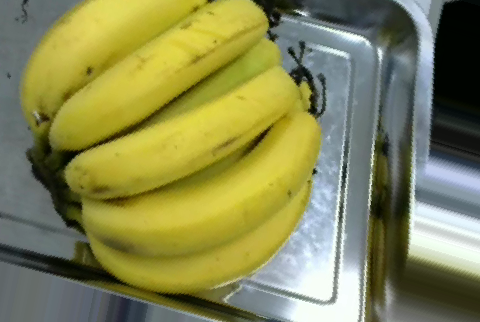

In [ ]:
folder_path = '/content/output_dataset/train/Banana__Healthy'

#List all files in the folder

image_files = [f for f in os.listdir (folder_path) if f.endswith(('.jpg','.png','.jpeg'))]

# Select a random image from the list

selected_image = random.choice(image_files)

# Display the randomly selected image

image_path = os.path.join(folder_path, selected_image)

display(Image(filename=image_path))

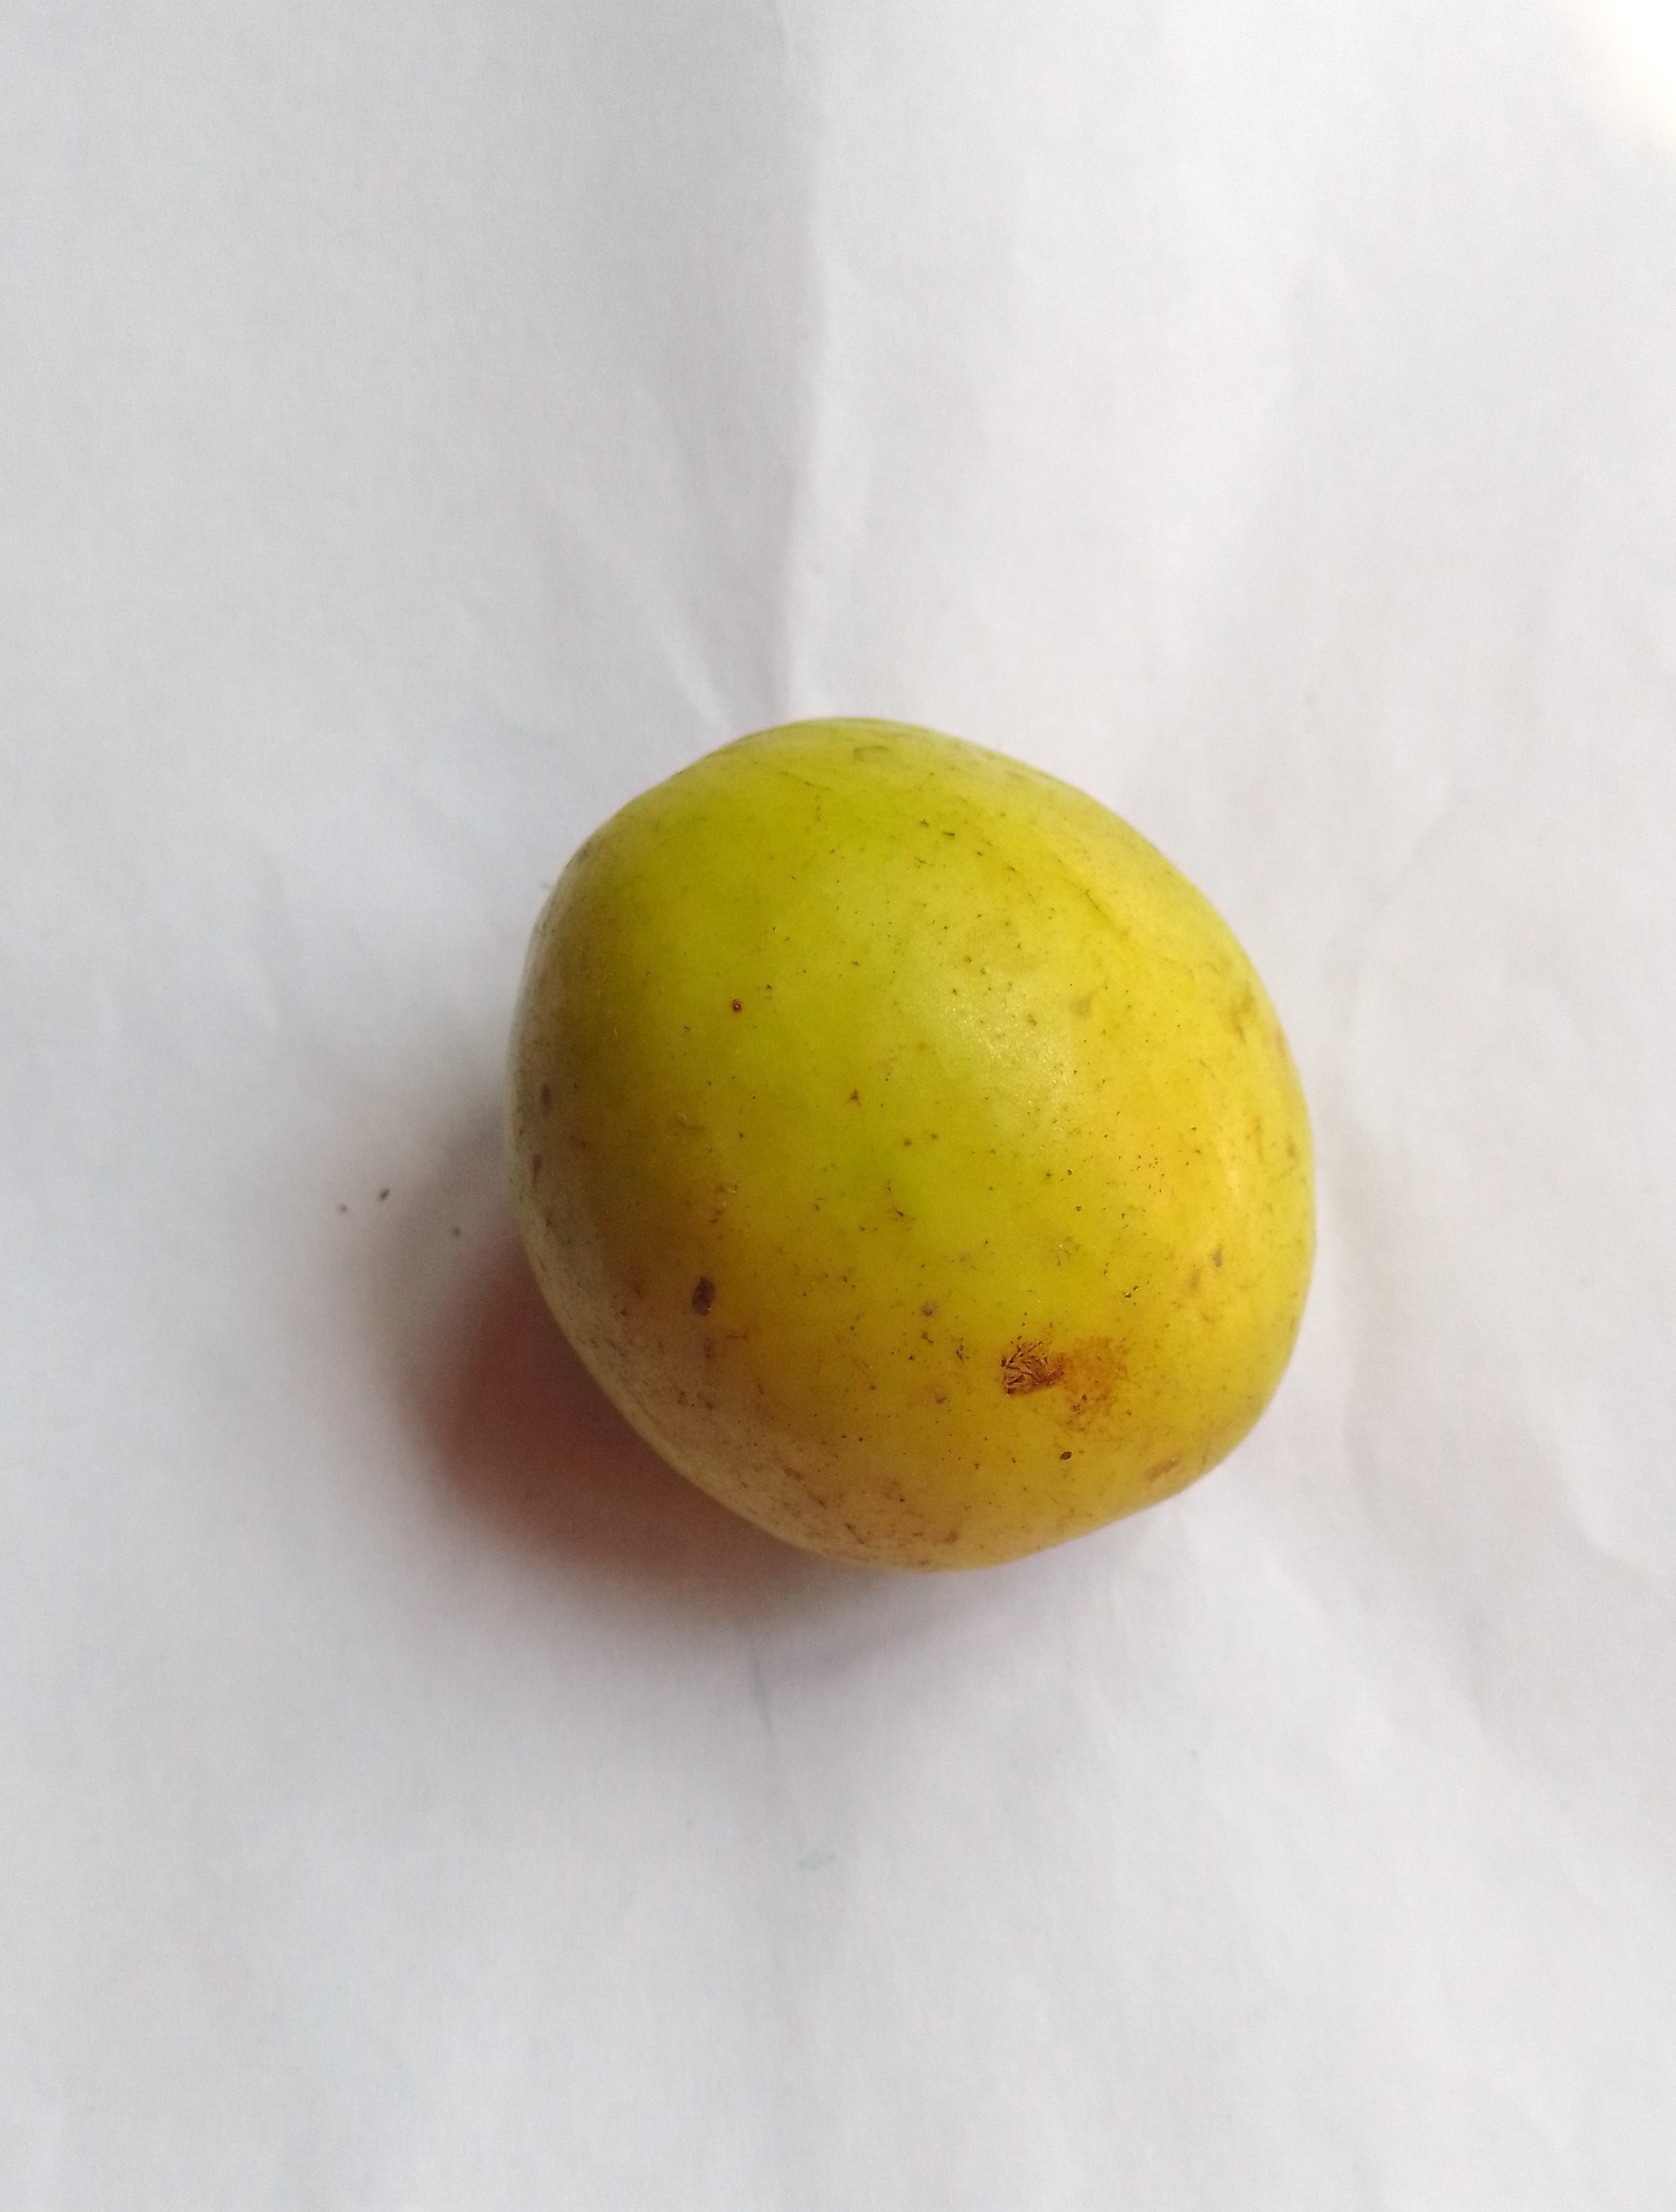

In [ ]:
folder_path = '/content/output_dataset/test/Jujube__Healthy'


#List all files in the folder

image_files = [f for f in os.listdir (folder_path) if f.endswith(('.jpg','.png','.jpeg'))]

# Select a random image from the list

selected_image = random.choice(image_files)

# Display the randomly selected image

image_path = os.path.join(folder_path, selected_image)

display(Image(filename=image_path))

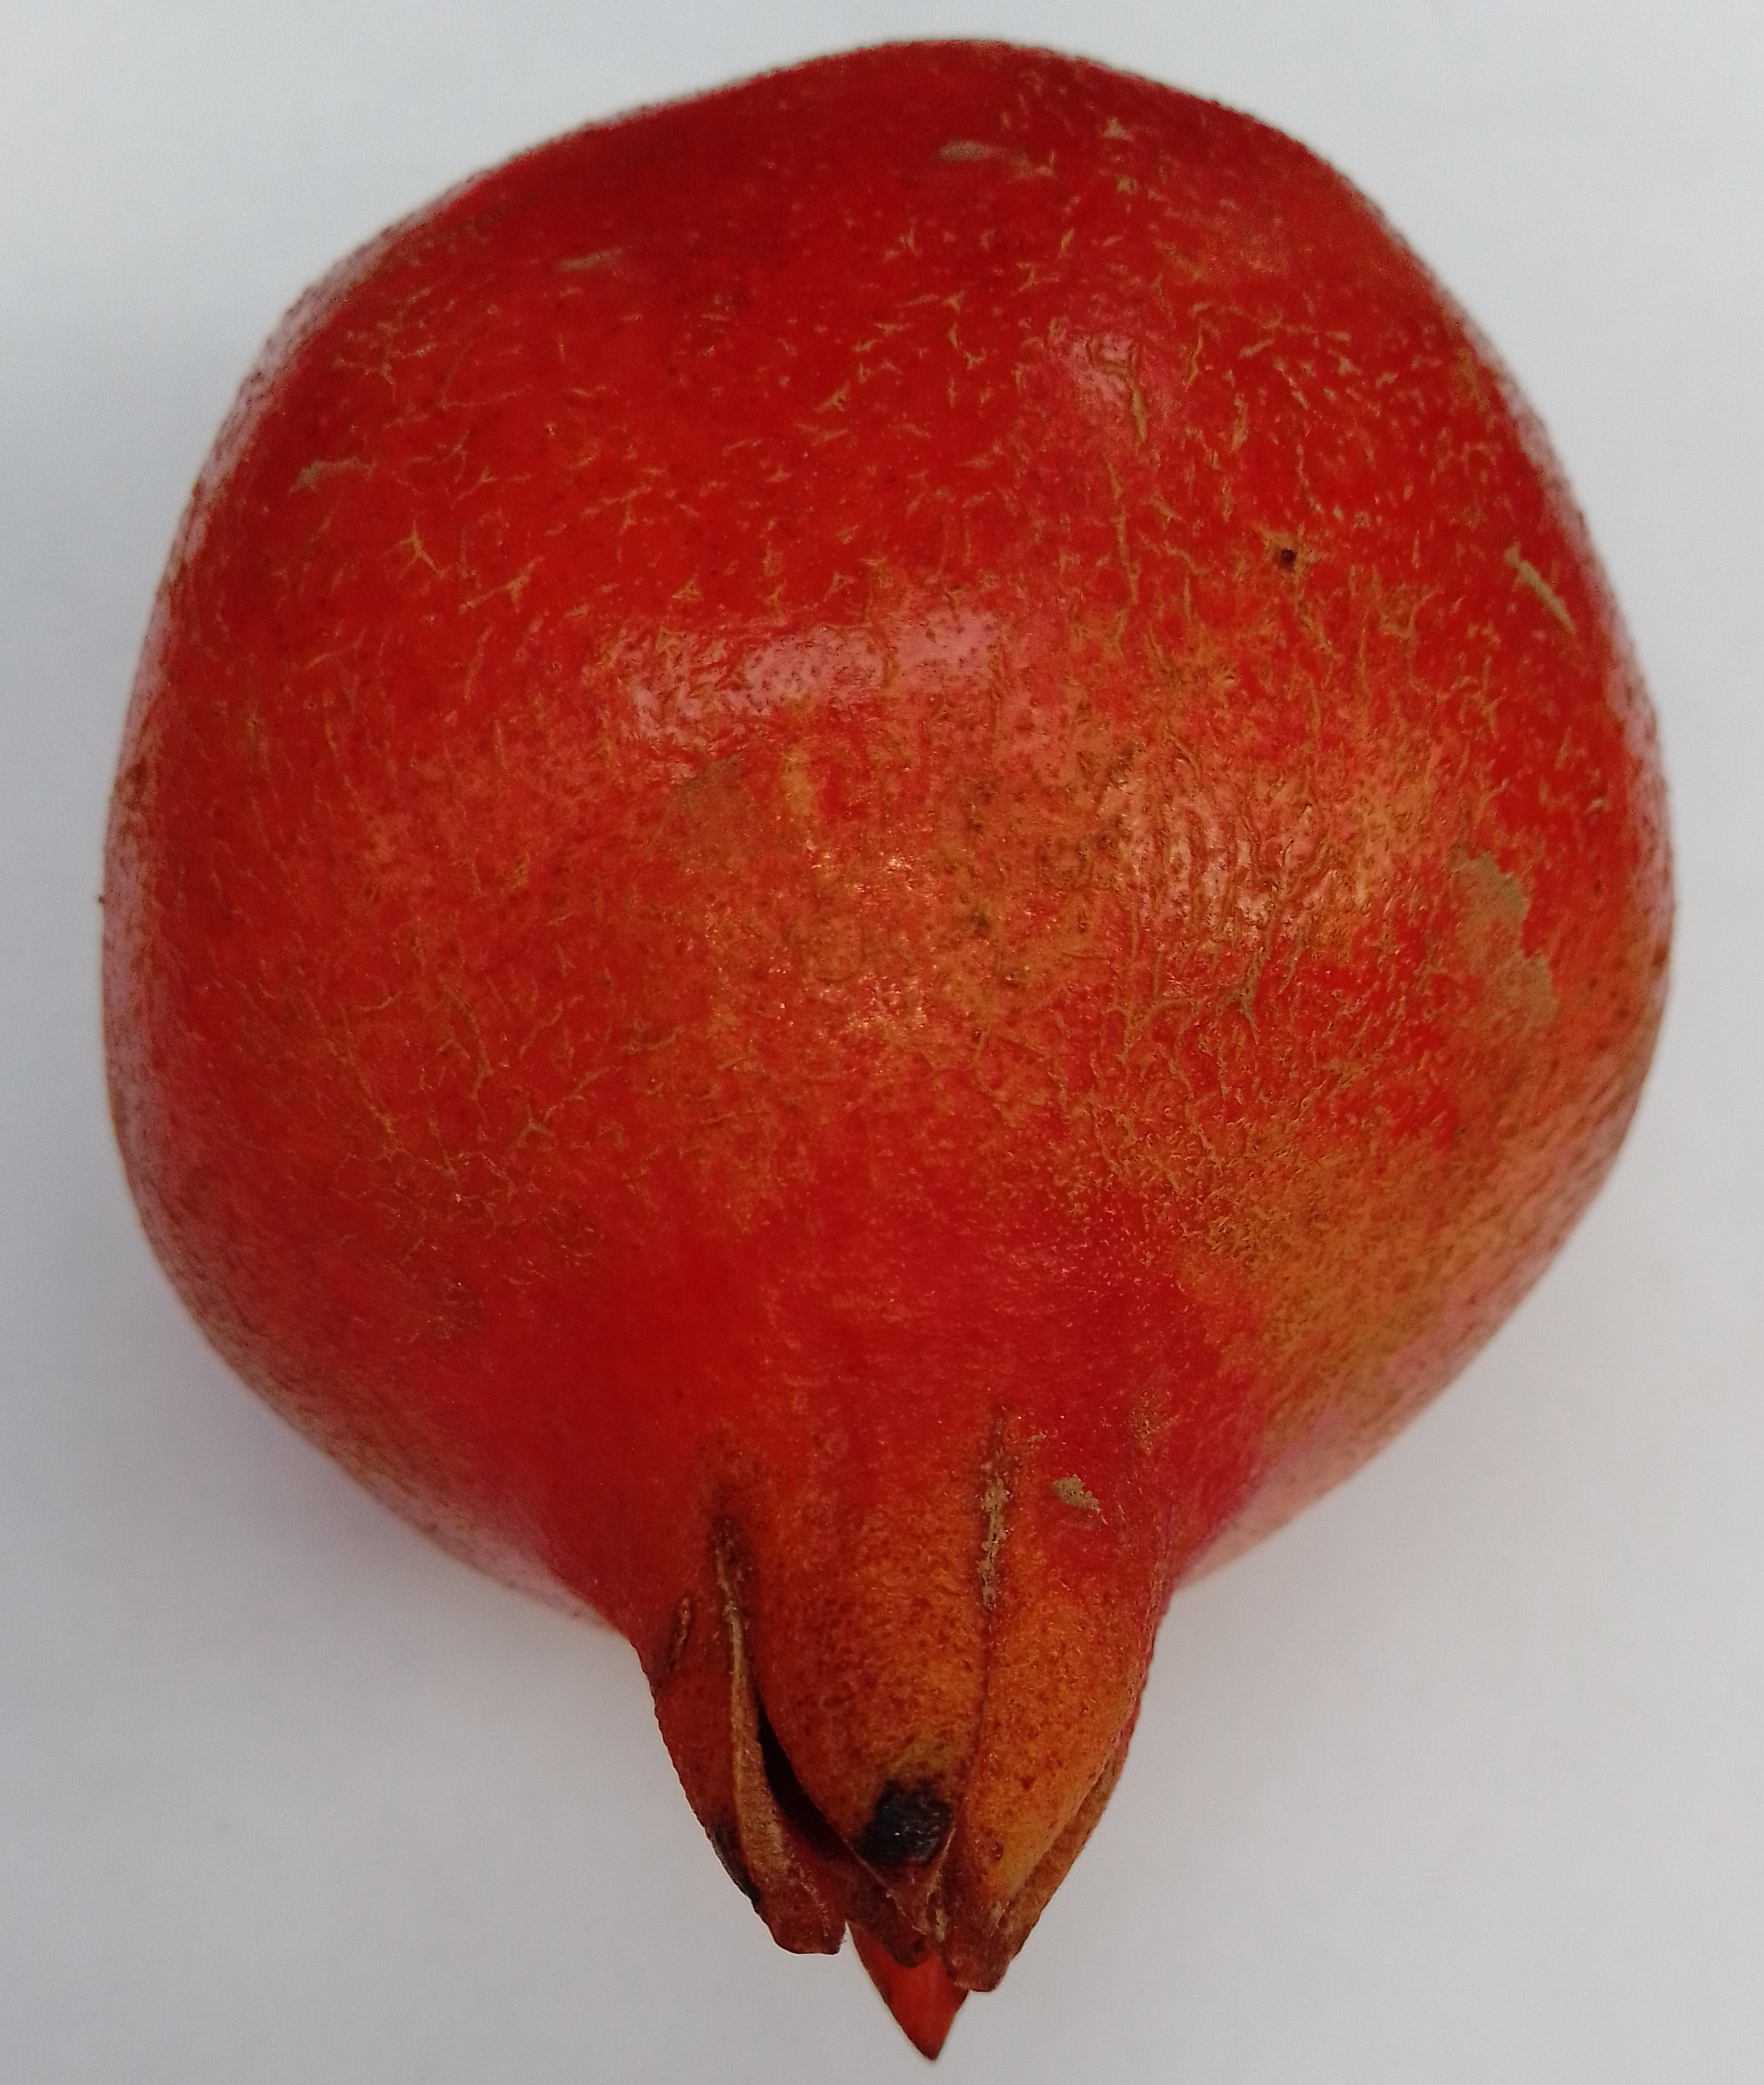

In [ ]:
folder_path = '/content/output_dataset/test/Pomegranate__Healthy'

#List all files in the folder

image_files = [f for f in os.listdir (folder_path) if f.endswith(('.jpg','.png','.jpeg'))]

# Select a random image from the list

selected_image = random.choice(image_files)

# Display the randomly selected image

image_path = os.path.join(folder_path, selected_image)

display(Image(filename=image_path))

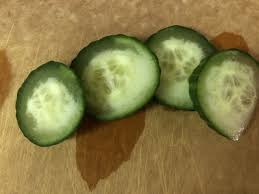

In [ ]:
folder_path = '/content/output_dataset/test/Cucumber__Rotten'


#List all files in the folder

image_files = [f for f in os.listdir (folder_path) if f.endswith(('.jpg','.png','.jpeg'))]

# Select a random image from the list

selected_image = random.choice(image_files)

# Display the randomly selected image

image_path = os.path.join(folder_path, selected_image)

display(Image(filename=image_path))

In [ ]:
trainpath = "/content/output_dataset/train"

testpath="/content/output_dataset/test"

train_datagen = ImageDataGenerator(rescale = 1./255,zoom_range= 0.2, shear_range= 0.2)

test_datagen = ImageDataGenerator (rescale = 1./255)

train = train_datagen.flow_from_directory (trainpath, target_size = (224,224), batch_size = 20)

test = test_datagen.flow_from_directory(testpath, target_size = (224,224), batch_size = 20)

Found 3358 images belonging to 28 classes.
Found 1119 images belonging to 28 classes.


In [ ]:
vgg=VGG16(include_top = False, input_shape=(224,224,3))


In [ ]:
for layer in vgg.layers:
  print(layer)

<InputLayer name=input_layer, built=True>
<Conv2D name=block1_conv1, built=True>
<Conv2D name=block1_conv2, built=True>
<MaxPooling2D name=block1_pool, built=True>
<Conv2D name=block2_conv1, built=True>
<Conv2D name=block2_conv2, built=True>
<MaxPooling2D name=block2_pool, built=True>
<Conv2D name=block3_conv1, built=True>
<Conv2D name=block3_conv2, built=True>
<Conv2D name=block3_conv3, built=True>
<MaxPooling2D name=block3_pool, built=True>
<Conv2D name=block4_conv1, built=True>
<Conv2D name=block4_conv2, built=True>
<Conv2D name=block4_conv3, built=True>
<MaxPooling2D name=block4_pool, built=True>
<Conv2D name=block5_conv1, built=True>
<Conv2D name=block5_conv2, built=True>
<Conv2D name=block5_conv3, built=True>
<MaxPooling2D name=block5_pool, built=True>


In [ ]:
len(vgg.layers)

19

In [ ]:
for layer in vgg.layers:
  layer.trainable=False

In [ ]:
x=Flatten()(vgg.output)

In [ ]:
output=Dense(28,activation='softmax')(x)

In [ ]:
vgg16= Model(vgg.input,output)

In [ ]:
vgg16.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 28)             │       702,492 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,417,180 (58.81 MB)

 Trainable params: 702,492 (2.68 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
opt = Adam(learning_rate=0.0001)

In [ ]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

In [ ]:
vgg16.compile(optimizer='adam' , loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history =vgg16.fit(train, validation_data=val_generator, epochs=15, steps_per_epoch=20, callbacks=[early_stopping])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.1198 - loss: 4.3349 - val_accuracy: 0.4066 - val_loss: 2.0860
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.4088 - loss: 2.3583 - val_accuracy: 0.5112 - val_loss: 1.7759
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5417 - loss: 1.7595 - val_accuracy: 0.5201 - val_loss: 1.6429
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5688 - loss: 1.5581 - val_accuracy: 0.5684 - val_loss: 1.5470
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6594 - loss: 1.1473 - val_accuracy: 0.6354 - val_loss: 1.2765
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6853 - loss: 1.0614 - val_accuracy: 0.6148 - val_loss: 1.2895
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7132 - loss: 1.1077 - val_accuracy: 0.6381 - val_loss: 1.3102
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 893ms/step - accuracy: 0.6806 - loss: 1.1111 - val_accuracy: 0.6881 - val_lo

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 816ms/step - accuracy: 0.7678 - loss: 0.7382 - val_accuracy: 0.6399 - val_loss: 1.2899
Epoch 10/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.7661 - loss: 0.8450 - val_accuracy: 0.6926 - val_loss: 1.0162
Epoch 11/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7994 - loss: 0.7487 - val_accuracy: 0.7033 - val_loss: 0.9728
Epoch 12/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7887 - loss: 0.7249 - val_accuracy: 0.7650 - val_loss: 0.8006
Epoch 13/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8617 - loss: 0.4978 - val_accuracy: 0.7310 - val_loss: 0.9478
Epoch 14/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8363 - loss: 0.5090 - val_accuracy: 0.7498 - val_loss: 0.8624
Epoch 15/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8706 - loss: 0.5087 - val_accuracy: 0.7471 - val_loss: 0.8650


In [ ]:
class_labels = train.class_indices
print(class_labels)
labels=dict((v,k) for k,v in class_labels.items())
print(labels)

{'Apple__Healthy': 0, 'Apple__Rotten': 1, 'Banana__Healthy': 2, 'Banana__Rotten': 3, 'Bellpepper__Healthy': 4, 'Bellpepper__Rotten': 5, 'Carrot__Healthy': 6, 'Carrot__Rotten': 7, 'Cucumber__Healthy': 8, 'Cucumber__Rotten': 9, 'Grape__Healthy': 10, 'Grape__Rotten': 11, 'Guava__Healthy': 12, 'Guava__Rotten': 13, 'Jujube__Healthy': 14, 'Jujube__Rotten': 15, 'Mango__Healthy': 16, 'Mango__Rotten': 17, 'Orange__Healthy': 18, 'Orange__Rotten': 19, 'Pomegranate__Healthy': 20, 'Pomegranate__Rotten': 21, 'Potato__Healthy': 22, 'Potato__Rotten': 23, 'Strawberry__Healthy': 24, 'Strawberry__Rotten': 25, 'Tomato__Healthy': 26, 'Tomato__Rotten': 27}
{0: 'Apple__Healthy', 1: 'Apple__Rotten', 2: 'Banana__Healthy', 3: 'Banana__Rotten', 4: 'Bellpepper__Healthy', 5: 'Bellpepper__Rotten', 6: 'Carrot__Healthy', 7: 'Carrot__Rotten', 8: 'Cucumber__Healthy', 9: 'Cucumber__Rotten', 10: 'Grape__Healthy', 11: 'Grape__Rotten', 12: 'Guava__Healthy', 13: 'Guava__Rotten', 14: 'Jujube__Healthy', 15: 'Jujube__Rotten', 

In [ ]:
img_path = '/content/output_dataset/train/Bellpepper__Healthy/freshPepper (110).jpg'


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]]


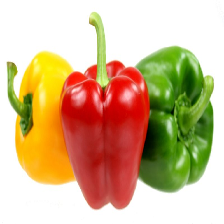

Image is tested successfully. 
 Image belongs to  Bellpepper__Healthy class.
100.0


In [ ]:
import numpy as np

img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = preprocess_input(x)
preds = vgg16.predict(np.array([x]))

print(preds)
display(img)
print("Image is tested successfully. \n Image belongs to ",labels[np.argmax(preds)],"class.")
confidence = round(float(np.max(preds)) * 100, 2)
print(confidence)


In [ ]:
img_path = '/content/output_dataset/train/Mango__Rotten/144.jpg'


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


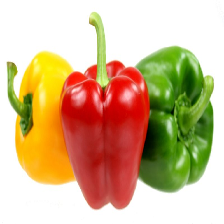

Image is tested successfully. 
 Image belongs to  Bellpepper__Healthy class.
100.0


In [ ]:
import numpy as np

img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = preprocess_input(x)
preds = vgg16.predict(np.array([x]))
display(img)
print("Image is tested successfully. \n Image belongs to ",labels[np.argmax(preds)],"class.")
confidence = round(float(np.max(preds)) * 100, 2)
print(confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


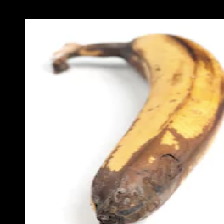

Predicted: Banana__Rotten
100.0


In [ ]:

# Pick random image
folder = '/content/output_dataset/val/Banana__Rotten'
img_name = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_name)

# Predict
img = load_img(img_path, target_size=(224, 224))
x = preprocess_input(img_to_array(img))
preds = vgg16.predict(np.array([x]))
predicted_class = labels[np.argmax(preds)]

# Display image and result
display(img)
print("Predicted:", predicted_class)
confidence = round(float(np.max(preds)) * 100, 2)
print(confidence)

In [ ]:
vgg16.save("vgg16_detector.h5")


In [ ]:
from google.colab import files
vgg16.save("vgg16_detector.h5")
files.download("vgg16_detector.h5")



In [ ]:
img_path ='/content/apple_rotten1.jpeg'

import numpy as np

img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = preprocess_input(x)
preds = vgg16.predict(np.array([x]))
print(preds)
display(img)
print("Image is tested successfully. \n Image belongs to ",labels[np.argmax(preds)],"class.")
confidence = round(float(np.max(preds)) * 100, 2)
print(confidence)


In [ ]:
# Make sure you're using tf.keras when training:
from tensorflow.keras.models import load_model

# Load your existing model if needed (if you have it in memory, skip this)
model = load_model('vgg16_detector.h5', compile=False)

# Re-save in new format:
model.save('vgg16_detector_tf2.h5')
files.download("vgg16_detector_tf2.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ValueError: The following argument(s) are not supported: ['compile']